In [1]:
import numpy as np
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from collections import defaultdict

np.random.seed(42)

In [2]:
with open('chain_rmscore_matrix_v2_avg.pkl', 'rb') as f:
    rmscore_matrix = pickle.load(f)

rmscore_matrix.keys()

dict_keys(['rmscore_matrix', 'pocket_names', 'pocket_files', 'n_pockets'])

In [3]:
# ============== Remove pockets with all-zero avg RMscore ==============
similarity_matrix = rmscore_matrix['rmscore_matrix']
pocket_names = rmscore_matrix['pocket_names']
n = len(pocket_names)

# Compute mean RMscore for each pocket (excluding diagonal)
row_means = np.array([
    np.concatenate([similarity_matrix[i, :i], similarity_matrix[i, i+1:]]).mean()
    for i in range(n)
])

# Identify pockets with avg off-diagonal RMscore == 0
zero_mask = row_means == 0
zero_idx = np.where(zero_mask)[0]
removed_pockets = [pocket_names[i] for i in zero_idx]

print(f"Found {len(zero_idx)} pockets with avg off-diagonal RMscore == 0:")
for idx in zero_idx:
    self_score = similarity_matrix[idx, idx]
    print(f"  Index {idx:4d} | {pocket_names[idx]:40s} | self_score={self_score:.4f}")

# Remove from rmscore_matrix
keep_mask = ~zero_mask
keep_idx = np.where(keep_mask)[0]
rmscore_matrix['rmscore_matrix'] = similarity_matrix[np.ix_(keep_idx, keep_idx)]
rmscore_matrix['pocket_names'] = [pocket_names[i] for i in keep_idx]

print(f"\nRemoved {len(removed_pockets)} pockets. Remaining: {len(rmscore_matrix['pocket_names'])} pockets")
print(f"New matrix shape: {rmscore_matrix['rmscore_matrix'].shape}")

Found 14 pockets with avg off-diagonal RMscore == 0:
  Index  856 | 6u6j_EQ4_A_pocket                        | self_score=1.0000
  Index  857 | 6u6j_EQ4_B_pocket                        | self_score=1.0000
  Index 1062 | 7u87_LXI_A_pocket                        | self_score=1.0000
  Index 1063 | 7u87_LXI_B_pocket                        | self_score=1.0000
  Index 1064 | 7u88_LXI_A_pocket                        | self_score=1.0000
  Index 1065 | 7u88_LXI_B_pocket                        | self_score=1.0000
  Index 1066 | 7u89_LXI_A_pocket                        | self_score=1.0000
  Index 1067 | 7u89_LXI_B_pocket                        | self_score=1.0000
  Index 1068 | 7u8a_LXI_A_pocket                        | self_score=1.0000
  Index 1069 | 7u8a_LXI_B_pocket                        | self_score=1.0000
  Index 1070 | 7u8b_LXR_A_pocket                        | self_score=1.0000
  Index 1243 | 8vaw_DGP_A_pocket                        | self_score=1.0000
  Index 1244 | 8vaw_DGP_B_pocket   

In [4]:
print(rmscore_matrix['rmscore_matrix'][0][:5])
print(f'Shape: {rmscore_matrix["rmscore_matrix"].shape}')

[1.       0.788815 0.251645 0.376965 0.345505]
Shape: (1232, 1232)


In [5]:
print(rmscore_matrix['pocket_names'][:5])
print(len(rmscore_matrix['pocket_names']))

['1aju_ARG_A_pocket', '1akx_ARG_A_pocket', '1am0_AMP_A_pocket', '1arj_ARG_N_pocket', '1eht_TEP_A_pocket']
1232


Loaded 1232 pocket names with RNA sequences
Unique RNA sequences: 375
Sequences shared by multiple pockets: 200

Cluster merging for RNA sequence constraint:
  Original clusters: 254
  Merges performed: 137
  Merged clusters: 145

cutoff=0.75, #samples per fold: [247, 247, 246, 246, 246]
Fold 0: Train=985 samples, Test=247 samples
Fold 1: Train=985 samples, Test=247 samples
Fold 2: Train=986 samples, Test=246 samples
Fold 3: Train=986 samples, Test=246 samples
Fold 4: Train=986 samples, Test=246 samples


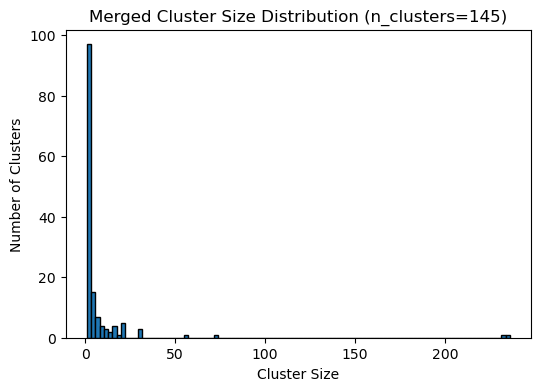

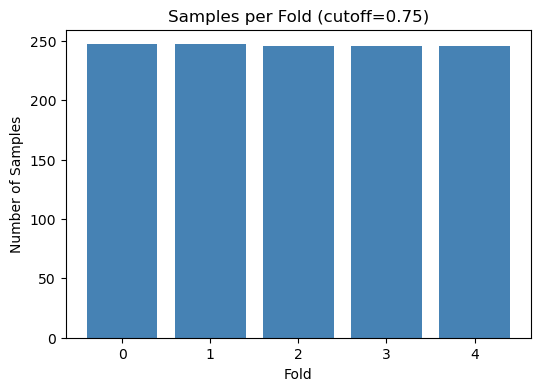

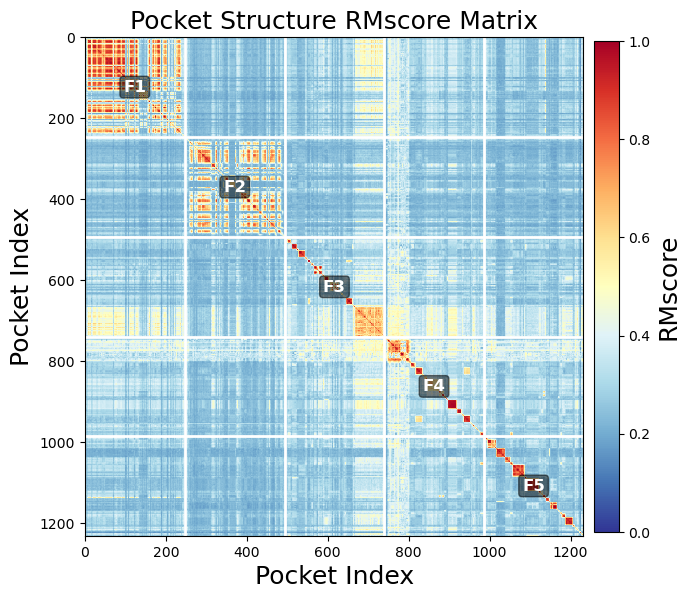

Saved: pocket_rmscore_matrix_by_fold.png

Statistic Summary (cutoff=0.75)
Number of merged clusters: 145
Fold sizes: [247, 247, 246, 246, 246]
Cluster size mean: 8.50, max: 236, min: 1
Singleton clusters: 62


In [6]:
cuttof = 0.75
n_folds = 5

# ============== Step 0: Load data to get RNA sequences per pocket ==============
with open('../data/hariboss_merged_5fd_with_decoys.pkl', 'rb') as f:
    data_original = pickle.load(f)

# Remove PDBs that contain zero-RMscore pockets (consistent with later cell)
removed_pdb_ids_tmp = set(pocket.split('_')[0] for pocket in removed_pockets)
for pdb_id in list(data_original.keys()):
    if pdb_id in removed_pdb_ids_tmp:
        del data_original[pdb_id]

# Build: pocket_name -> set of rna_chain_sequences
pocket_to_seqs = defaultdict(set)
for pdb_id, pdb_data in data_original.items():
    for complex_key, sample_data in pdb_data.items():
        ligand_id = sample_data['ligand_id']
        rna_chain_id = sample_data['rna_chain_id']
        pocket_name = f"{pdb_id}_{ligand_id}_{rna_chain_id}_pocket"
        pocket_to_seqs[pocket_name].add(sample_data['rna_chain_sequence'])

# Build: rna_chain_sequence -> set of pocket_names
seq_to_pockets = defaultdict(set)
for pocket_name, seqs in pocket_to_seqs.items():
    for seq in seqs:
        seq_to_pockets[seq].add(pocket_name)

print(f'Loaded {len(pocket_to_seqs)} pocket names with RNA sequences')
print(f'Unique RNA sequences: {len(seq_to_pockets)}')
multi_pocket_seqs = {s: p for s, p in seq_to_pockets.items() if len(p) > 1}
print(f'Sequences shared by multiple pockets: {len(multi_pocket_seqs)}')

# ============== Step 1: AgglomerativeClustering (RNAmigos2 style) ==============
distance_matrix = 1.0 - rmscore_matrix['rmscore_matrix']

clustering = AgglomerativeClustering(
    metric='precomputed',
    n_clusters=None,
    compute_full_tree=True,
    linkage='single',
    distance_threshold=1.0 - cuttof  # 0.25
).fit(distance_matrix)

cluster_labels = clustering.labels_

cluster_df = pd.DataFrame({'pocket_name': rmscore_matrix['pocket_names'], 'cluster': cluster_labels})
pocket_to_cluster = dict(zip(cluster_df['pocket_name'], cluster_df['cluster']))

# ============== Step 2: Merge clusters sharing the same RNA sequence (Union-Find) ==============
parent = {}

def find(x):
    while parent.get(x, x) != x:
        parent[x] = parent.get(parent[x], parent[x])  # path compression
        x = parent[x]
    return x

def union(a, b):
    ra, rb = find(a), find(b)
    if ra != rb:
        parent[ra] = rb

# For each shared RNA sequence, union all clusters of its pockets
merges_done = 0
for seq, pockets in seq_to_pockets.items():
    # Get clusters for these pockets (only those in the rmscore matrix)
    clusters_for_seq = set()
    for p in pockets:
        if p in pocket_to_cluster:
            clusters_for_seq.add(pocket_to_cluster[p])
    
    if len(clusters_for_seq) > 1:
        clusters_list = list(clusters_for_seq)
        for i in range(1, len(clusters_list)):
            union(clusters_list[0], clusters_list[i])
            merges_done += 1

# Re-label clusters based on Union-Find roots
cluster_df['merged_cluster'] = cluster_df['cluster'].apply(find)
n_original = cluster_df['cluster'].nunique()
n_merged = cluster_df['merged_cluster'].nunique()
print(f'\nCluster merging for RNA sequence constraint:')
print(f'  Original clusters: {n_original}')
print(f'  Merges performed: {merges_done}')
print(f'  Merged clusters: {n_merged}')

# ============== Step 3: Greedy fold assignment (using merged clusters) ==============
cluster_sample_counts = cluster_df.groupby('merged_cluster').size().to_dict()
unique_clusters = list(cluster_sample_counts.keys())
unique_clusters_sorted = sorted(unique_clusters, key=lambda c: cluster_sample_counts[c], reverse=True)

fold_clusters = {i: [] for i in range(n_folds)}
fold_sample_counts = {i: 0 for i in range(n_folds)}
for cluster_id in unique_clusters_sorted:
    min_fold = min(fold_sample_counts, key=fold_sample_counts.get)
    fold_clusters[min_fold].append(cluster_id)
    fold_sample_counts[min_fold] += cluster_sample_counts[cluster_id]
fold_sizes = list(fold_sample_counts.values())
print(f'\ncutoff={cuttof}, #samples per fold: {fold_sizes}')

# ============== Step 4: Generate 5-fold splits ==============
fold_splits = []
for test_fold in range(n_folds):
    test_clusters = set(fold_clusters[test_fold])
    train_clusters = set()
    for train_fold in range(n_folds):
        if train_fold != test_fold:
            train_clusters.update(fold_clusters[train_fold])
    train_pockets = cluster_df[cluster_df['merged_cluster'].isin(train_clusters)]['pocket_name'].tolist()
    test_pockets = cluster_df[cluster_df['merged_cluster'].isin(test_clusters)]['pocket_name'].tolist()
    fold_splits.append({
        'fold': test_fold,
        'train_clusters': train_clusters,
        'test_clusters': test_clusters,
        'train_pockets': train_pockets,
        'test_pockets': test_pockets
    })
    print(f'Fold {test_fold}: Train={len(train_pockets)} samples, Test={len(test_pockets)} samples')

# ============== Step 5: Visualization ==============
# plot distribution of merged cluster sizes
cluster_sizes = cluster_df['merged_cluster'].value_counts().sort_index()
plt.figure(figsize=(6,4))
plt.hist(cluster_sizes.values, bins=100, edgecolor='black')
plt.xlabel('Cluster Size')
plt.ylabel('Number of Clusters')
plt.title(f'Merged Cluster Size Distribution (n_clusters={len(cluster_sizes)})')
plt.show()

# plot fold sizes
plt.figure(figsize=(6,4))
plt.bar(range(n_folds), fold_sizes, color='steelblue')
plt.xlabel('Fold')
plt.ylabel('Number of Samples')
plt.title(f'Samples per Fold (cutoff={cuttof})')
plt.show()

# plot similarity matrix (reordered by fold)
similarity_matrix = rmscore_matrix['rmscore_matrix']
pocket_names_list = list(rmscore_matrix['pocket_names'])

pocket_to_fold_tmp = {}
for fold_id, clusters in fold_clusters.items():
    for pocket in cluster_df[cluster_df['merged_cluster'].isin(clusters)]['pocket_name']:
        pocket_to_fold_tmp[pocket] = fold_id

fold_of_each = [pocket_to_fold_tmp[p] for p in pocket_names_list]
cluster_of_each = list(cluster_df['merged_cluster'].values)

# Sort by (fold, cluster) for block-diagonal structure
sorted_indices = sorted(range(len(pocket_names_list)),
                        key=lambda i: (fold_of_each[i], cluster_of_each[i]))
sorted_folds = [fold_of_each[i] for i in sorted_indices]
reordered_matrix = similarity_matrix[np.ix_(sorted_indices, sorted_indices)]

# Find fold boundaries
fold_boundaries = []
for f in range(n_folds):
    fold_start = sorted_folds.index(f)
    fold_end = len(sorted_folds) - 1 - sorted_folds[::-1].index(f)
    fold_boundaries.append((fold_start, fold_end))

fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(reordered_matrix, cmap='RdYlBu_r', vmin=0, vmax=1, aspect='equal')
ax.set_title('Pocket Structure RMscore Matrix', fontsize=18)
ax.set_xlabel('Pocket Index', fontsize=18)
ax.set_ylabel('Pocket Index', fontsize=18)
cbar = fig.colorbar(im, ax=ax, shrink=1.0, label='RMscore', pad=0.02, fraction=0.046)
cbar.set_label('RMscore', fontsize=18)

for f, (start, end) in enumerate(fold_boundaries):
    if f > 0:
        ax.axhline(y=start - 0.5, color='white', linewidth=2)
        ax.axvline(x=start - 0.5, color='white', linewidth=2)
    mid = (start + end) / 2
    ax.text(mid, mid, f'F{f+1}', ha='center', va='center',
            fontsize=12, fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.5))

plt.tight_layout()
plt.savefig('pocket_rmscore_matrix_by_fold.png', dpi=600, bbox_inches='tight')
plt.show()
print("Saved: pocket_rmscore_matrix_by_fold.png")

# output summary statistics
print(f'\nStatistic Summary (cutoff={cuttof})')
print(f'Number of merged clusters: {len(cluster_sizes)}')
print(f'Fold sizes: {fold_sizes}')
print(f'Cluster size mean: {cluster_sizes.mean():.2f}, max: {cluster_sizes.max()}, min: {cluster_sizes.min()}')
print(f'Singleton clusters: {(cluster_sizes==1).sum()}')

In [7]:
fold_test_pockets = [fold_splits[i]['test_pockets'] for i in range(5)]
fold_test_pockets[0][0]

'1am0_AMP_A_pocket'

In [8]:
with open('../data/hariboss_merged_5fd_with_decoys.pkl', 'rb') as f:
    data = pickle.load(f)

# Remove entire PDBs that contain zero-RMscore pockets
removed_pdb_ids = set(pocket.split('_')[0] for pocket in removed_pockets)
for pdb_id in removed_pdb_ids:
    if pdb_id in data:
        del data[pdb_id]
        print(f'  Removed PDB: {pdb_id}')
    else:
        print(f'  Warning: PDB {pdb_id} not found in data')

print(f"\nRemoved {len(removed_pdb_ids)} PDBs from pkl data")
total_samples = sum(len(v) for v in data.values())
print(f"Remaining samples in pkl: {total_samples}")

  Removed PDB: 8vax
  Removed PDB: 7u87
  Removed PDB: 6u6j
  Removed PDB: 7u8b
  Removed PDB: 7u8a
  Removed PDB: 8vaw
  Removed PDB: 7u89
  Removed PDB: 7u88

Removed 8 PDBs from pkl data
Remaining samples in pkl: 1232


In [9]:
for i in range(5):
    fold_pockets = fold_test_pockets[i]
    for pocket in fold_pockets:
        pdb_id = pocket.split('_')[0]
        ligand_id = pocket.split('_')[1]
        rna_chain_id = pocket.split('_')[2]
        
        if pdb_id not in data:
            print(f'Error: PDB {pdb_id} not found in data')
            continue
            
        v = data[pdb_id]
        no_match = True
        for keys in v.keys():
            if keys.startswith(f'{pdb_id}_{rna_chain_id}') and ligand_id in keys:
                train_split = [True] * 5
                train_split[i] = False
                data[pdb_id][keys]['train_split'] = train_split 
                no_match = False
                break
        if no_match:
            print(f'Error key: {pocket}')

print(f"Totally {sum(len(pockets) for pockets in fold_test_pockets)} pockets")

# save 
with open('../data/hariboss_5fd_by_pocket_structure_no_identity.pkl', 'wb') as f:
    pickle.dump(data, f)

print("Save to ../data/hariboss_5fd_by_pocket_structure_no_identity.pkl")

Totally 1232 pockets
Save to ../data/hariboss_5fd_by_pocket_structure_no_identity.pkl


In [ ]:
# Unit test
def validate_pocket_split(saved_data, fold_test_pockets, cluster_df, removed_pockets):
    print("Unit Test: verify Pocket Structure Split")
    
    all_passed = True
    
    print("\n[Test 1] Every pocket only appears in one fold.")
    pocket_fold_map = {}
    for fold_idx, pockets in enumerate(fold_test_pockets):
        for pocket in pockets:
            if pocket in pocket_fold_map:
                print(f"  Fail: Pocket '{pocket}' appears in multiple folds: {pocket_fold_map[pocket]} and {fold_idx}")
                all_passed = False
            else:
                pocket_fold_map[pocket] = fold_idx
    
    if all(p in pocket_fold_map for p in rmscore_matrix['pocket_names']):
        print(f"  Pass: All {len(pocket_fold_map)} pockets only appear in one fold.")
    else:
        missing = [p for p in rmscore_matrix['pocket_names'] if p not in pocket_fold_map]
        print(f"  Fail: {len(missing)} pockets not assigned to any fold")
        all_passed = False
    
    print("\n[Test 2] Total samples match (after removing zero-RMscore pockets).")
    total_pockets = len(rmscore_matrix['pocket_names'])
    actual_counts = [len(pockets) for pockets in fold_test_pockets]
    if sum(actual_counts) == total_pockets:
        print(f"  Pass: Total pockets match: {sum(actual_counts)} == {total_pockets}, fold sizes: {actual_counts}")
    else:
        print(f"  Fail: Total {sum(actual_counts)} != expected {total_pockets}, fold sizes: {actual_counts}")
        all_passed = False
    
    print("\n[Test 3] Pockets in the same merged cluster are in the same fold (check data leakage).")
    leakage_count = 0
    for cluster_id in cluster_df['merged_cluster'].unique():
        cluster_pockets = cluster_df[cluster_df['merged_cluster'] == cluster_id]['pocket_name'].tolist()
        cluster_folds = set()
        for pocket in cluster_pockets:
            if pocket in pocket_fold_map:
                cluster_folds.add(pocket_fold_map[pocket])
        if len(cluster_folds) > 1:
            leakage_count += 1
            if leakage_count <= 3: 
                print(f"  Fail: Merged cluster {cluster_id} pockets are distributed in multiple folds: {cluster_folds}")
    
    if leakage_count == 0:
        print(f"  Pass: All {len(cluster_df['merged_cluster'].unique())} merged clusters have no data leakage")
    else:
        print(f"  Fail: {leakage_count} merged clusters have data leakage")
        all_passed = False
    
    print("\n[Test 4] Verify train_split in saved data.")
    samples_with_split = 0
    samples_without_split = 0
    incorrect_splits = 0
    
    for pdb_id, pdb_data in saved_data.items():
        for complex_key, sample_data in pdb_data.items():
            ligand_id = sample_data.get('ligand_id')
            rna_chain_id = sample_data.get('rna_chain_id')
            pocket_name = f"{pdb_id}_{ligand_id}_{rna_chain_id}_pocket"
            
            train_split = sample_data.get('train_split')
            
            if train_split is None:
                samples_without_split += 1
            else:
                samples_with_split += 1
                if len(train_split) != 5:
                    incorrect_splits += 1
                elif train_split.count(False) != 1:
                    incorrect_splits += 1
                else:
                    expected_test_fold = pocket_fold_map.get(pocket_name)
                    if expected_test_fold is not None:
                        actual_test_fold = train_split.index(False)
                        if actual_test_fold != expected_test_fold:
                            incorrect_splits += 1
    
    print(f"  Samples with train_split: {samples_with_split}")
    print(f"  Samples without train_split: {samples_without_split}")
    
    if samples_without_split == 0 and incorrect_splits == 0:
        print(f"  Pass: All {samples_with_split} samples have correct train_split")
    else:
        if samples_without_split > 0:
            print(f"  Fail: {samples_without_split} samples missing train_split")
        if incorrect_splits > 0:
            print(f"  Fail: {incorrect_splits} samples have incorrect train_split format or value")
        all_passed = False
    
    print(f"\n[Test 5] Removed pockets ({len(removed_pockets)}) are NOT in any fold or saved data.")
    removed_in_fold = [p for p in removed_pockets if p in pocket_fold_map]
    if len(removed_in_fold) == 0:
        print(f"  Pass: None of the {len(removed_pockets)} removed pockets appear in any fold")
    else:
        print(f"  Fail: {len(removed_in_fold)} removed pockets still in folds: {removed_in_fold}")
        all_passed = False
    
    # Check removed pockets are not in saved data
    removed_in_data = 0
    for pocket in removed_pockets:
        parts = pocket.replace('_pocket', '').split('_')
        pdb_id, ligand_id, rna_chain_id = parts[0], parts[1], parts[2]
        if pdb_id in saved_data:
            for keys in saved_data[pdb_id].keys():
                if keys.startswith(f'{pdb_id}_{rna_chain_id}') and ligand_id in keys:
                    removed_in_data += 1
                    break
    if removed_in_data == 0:
        print(f"  Pass: None of the {len(removed_pockets)} removed pockets appear in saved data")
    else:
        print(f"  Fail: {removed_in_data} removed pockets still in saved data")
        all_passed = False
    
    print(f"\n[Test 6] Identical rna_chain_sequence must NOT appear in different folds.")
    seq_to_folds = defaultdict(set)
    for pdb_id, pdb_data in saved_data.items():
        for complex_key, sample_data in pdb_data.items():
            test_fold = sample_data['train_split'].index(False)
            seq = sample_data['rna_chain_sequence']
            seq_to_folds[seq].add(test_fold)
    
    shared_seqs = {seq: folds for seq, folds in seq_to_folds.items() if len(folds) > 1}
    if len(shared_seqs) == 0:
        print(f"  Pass: No identical rna_chain_sequence appears in different folds ({len(seq_to_folds)} unique sequences)")
    else:
        print(f"  Fail: {len(shared_seqs)} sequences appear in multiple folds")
        for seq, folds in list(shared_seqs.items())[:5]:
            print(f"    Seq (len={len(seq)}): folds {sorted(folds)}, first 80 chars: {seq[:80]}")
        all_passed = False
    
    if all_passed:
        print("\n  All tests passed!")
    else:
        print("\n  Some tests failed, please check the above errors")
    
    return all_passed

with open('../data/hariboss_5fd_by_pocket_structure_no_identity.pkl', 'rb') as f:
    saved_data = pickle.load(f)

validate_pocket_split(saved_data, fold_test_pockets, cluster_df, removed_pockets)

Unit Test: verify Pocket Structure Split

[Test 1] Every pocket only appears in one fold.
  Pass: All 1232 pockets only appear in one fold.

[Test 2] Total samples match (after removing zero-RMscore pockets).
  Pass: Total pockets match: 1232 == 1232, fold sizes: [247, 247, 246, 246, 246]

[Test 3] Pockets in the same merged cluster are in the same fold (check data leakage).
  Pass: All 145 merged clusters have no data leakage

[Test 4] Verify train_split in saved data.
  Samples with train_split: 1232
  Samples without train_split: 0
  Pass: All 1232 samples have correct train_split

[Test 5] Removed pockets (14) are NOT in any fold or saved data.
  Pass: None of the 14 removed pockets appear in any fold
  Pass: None of the 14 removed pockets appear in saved data

[Test 6] Identical rna_chain_sequence must NOT appear in different folds.
  Pass: No identical rna_chain_sequence appears in different folds (375 unique sequences)

  All tests passed!


True

In [11]:
# ============== Double Check: No train-test leakage above RMscore threshold ==============
# For each fold, verify that max RMscore between any train pocket and any test pocket < CUTOFF
CUTOFF = 0.75
N_FOLDS = 5
similarity_matrix = rmscore_matrix['rmscore_matrix']
pocket_names = rmscore_matrix['pocket_names']
name_to_idx = {name: idx for idx, name in enumerate(pocket_names)}

print(f"Checking train-test RMscore leakage for each fold (threshold={CUTOFF})...\n")

all_passed = True
for fold_id in range(N_FOLDS):
    # Get test and train pocket names for this fold
    test_clusters = fold_clusters[fold_id]
    test_pockets = cluster_df[cluster_df['merged_cluster'].isin(test_clusters)]['pocket_name'].tolist()
    train_pockets = cluster_df[~cluster_df['merged_cluster'].isin(test_clusters)]['pocket_name'].tolist()
    
    # Get indices
    test_idx = [name_to_idx[p] for p in test_pockets]
    train_idx = [name_to_idx[p] for p in train_pockets]
    
    # Extract pairwise RMscore between train and test
    pairwise = similarity_matrix[np.ix_(train_idx, test_idx)]
    max_score = pairwise.max()
    
    # Find violations (pairs with RMscore >= CUTOFF)
    violations = np.argwhere(pairwise >= CUTOFF)
    n_violations = len(violations)
    
    status = "PASSED" if n_violations == 0 else "FAILED"
    if n_violations > 0:
        all_passed = False
    
    print(f"Fold {fold_id}: {status} | "
          f"train={len(train_pockets)}, test={len(test_pockets)} | "
          f"max RMscore={max_score:.4f} | "
          f"violations (>={CUTOFF}): {n_violations}")
    
    # Show top violations if any
    if n_violations > 0:
        scores = [(train_pockets[i], test_pockets[j], pairwise[i, j]) 
                  for i, j in violations]
        scores.sort(key=lambda x: -x[2])
        for train_p, test_p, score in scores[:5]:
            print(f"    {train_p} <-> {test_p}: RMscore={score:.4f}")
        if n_violations > 5:
            print(f"    ... and {n_violations - 5} more")

print(f"\n{'='*50}")
print(f"Overall: {'ALL FOLDS PASSED' if all_passed else 'SOME FOLDS FAILED'}")
print(f"No train-test pair exceeds RMscore >= {CUTOFF}: {all_passed}")

Checking train-test RMscore leakage for each fold (threshold=0.75)...

Fold 0: PASSED | train=985, test=247 | max RMscore=0.7441 | violations (>=0.75): 0
Fold 1: PASSED | train=985, test=247 | max RMscore=0.7346 | violations (>=0.75): 0
Fold 2: PASSED | train=986, test=246 | max RMscore=0.7492 | violations (>=0.75): 0
Fold 3: PASSED | train=986, test=246 | max RMscore=0.7412 | violations (>=0.75): 0
Fold 4: PASSED | train=986, test=246 | max RMscore=0.7492 | violations (>=0.75): 0

Overall: ALL FOLDS PASSED
No train-test pair exceeds RMscore >= 0.75: True


In [12]:
# ============== Check: Identical rna_chain_sequence across different folds ==============

# Build: rna_chain_sequence -> list of (pdb_id, ligand_id, chain_id, complex_key, fold)
seq_to_samples = defaultdict(list)

with open('../data/hariboss_5fd_by_pocket_structure_no_identity.pkl', 'rb') as f:
    saved_data_check = pickle.load(f)

for pdb_id, pdb_data in saved_data_check.items():
    for complex_key, sample_data in pdb_data.items():
        test_fold = sample_data['train_split'].index(False)
        seq = sample_data['rna_chain_sequence']
        seq_to_samples[seq].append({
            'pdb_id': sample_data['pdb_id'],
            'ligand_id': sample_data['ligand_id'],
            'rna_chain_id': sample_data['rna_chain_id'],
            'complex_key': complex_key,
            'fold': test_fold,
            'seq_len': len(seq)
        })

# Find sequences that appear in more than one fold
shared_seqs = {}
for seq, samples in seq_to_samples.items():
    folds = set(s['fold'] for s in samples)
    if len(folds) > 1:
        shared_seqs[seq] = samples

print("=" * 120)
print("Identical rna_chain_sequence appearing in DIFFERENT folds")
print("=" * 120)
print(f"\nTotal unique sequences: {len(seq_to_samples)}")
print(f"Sequences appearing in multiple folds: {len(shared_seqs)}")

if shared_seqs:
    sorted_seqs = sorted(shared_seqs.items(), 
                         key=lambda x: (-len(set(s['fold'] for s in x[1])), -len(x[0])))
    
    for i, (seq, samples) in enumerate(sorted_seqs):
        folds = sorted(set(s['fold'] for s in samples))
        print(f"\n{'─' * 120}")
        print(f"Sequence #{i+1} | Length: {len(seq)} | Folds: {folds} | Total samples: {len(samples)}")
        print(f"Sequence: {seq[:100]}{'...' if len(seq) > 100 else ''}")
        print(f"  {'PDB':<8s} | {'Ligand':<10s} | {'Chain':<8s} | {'Fold':<6s} | Complex Key")
        print(f"  {'-' * 90}")
        for fold_id in folds:
            fold_samples = [s for s in samples if s['fold'] == fold_id]
            for s in fold_samples:
                print(f"  {s['pdb_id']:<8s} | {s['ligand_id']:<10s} | {s['rna_chain_id']:<8s} | {s['fold']:<6d} | {s['complex_key']}")

    # Summary table
    print(f"\n{'=' * 120}")
    print("Summary: Shared sequences grouped by unique PDB count")
    print("=" * 120)
    for i, (seq, samples) in enumerate(sorted_seqs):
        folds = sorted(set(s['fold'] for s in samples))
        pdbs = sorted(set(s['pdb_id'] for s in samples))
        print(f"  Seq #{i+1} (len={len(seq):4d}): {len(folds)} folds, {len(pdbs)} PDBs ({', '.join(pdbs[:10])})")
else:
    print("\nNo identical rna_chain_sequence found across different folds!")

Identical rna_chain_sequence appearing in DIFFERENT folds

Total unique sequences: 375
Sequences appearing in multiple folds: 0

No identical rna_chain_sequence found across different folds!


In [13]:
# ============== Diagnose: Why do some PDB keys appear in multiple folds? ==============

print("="*100)
print("Root cause: Same PDB has multiple pockets assigned to different folds")
print("="*100)

# For each PDB, show which pockets are in which fold
pdb_to_pockets_per_fold = defaultdict(lambda: defaultdict(list))

for pdb_id, pdb_data in saved_data_check.items():
    for complex_key, sample_data in pdb_data.items():
        ligand_id = sample_data['ligand_id']
        rna_chain_id = sample_data['rna_chain_id']
        pocket_name = f"{pdb_id}_{ligand_id}_{rna_chain_id}_pocket"
        test_fold = sample_data['train_split'].index(False)
        pdb_to_pockets_per_fold[pdb_id][test_fold].append(pocket_name)

# Only show PDBs in multiple folds
shared_pdbs = {k: v for k, v in pdb_to_pockets_per_fold.items() if len(v) > 1}

print(f"\n{len(shared_pdbs)} PDBs have pockets in multiple folds:\n")
print(f"{'PDB':<10s} | {'#Folds':<7s} | Fold -> Pockets")
print("-"*100)
for pdb_id in sorted(shared_pdbs, key=lambda x: -len(shared_pdbs[x])):
    fold_info = shared_pdbs[pdb_id]
    n_folds_in = len(fold_info)
    detail_parts = []
    for fold_id in sorted(fold_info):
        pockets = sorted(set(fold_info[fold_id]))
        detail_parts.append(f"F{fold_id}: {', '.join(pockets)}")
    detail_str = '  |  '.join(detail_parts)
    print(f"{pdb_id:<10s} | {n_folds_in:<7d} | {detail_str}")

# Check: are these cross-fold pockets structurally dissimilar?
print(f"\n{'='*100}")
print(f"Cross-fold pocket pairs from same PDB: check their RMscore")
print(f"{'='*100}")

name_to_idx_diag = {name: idx for idx, name in enumerate(rmscore_matrix['pocket_names'])}
sim_matrix_diag = rmscore_matrix['rmscore_matrix']

high_score_pairs = []
for pdb_id, fold_info in shared_pdbs.items():
    folds = sorted(fold_info.keys())
    for i in range(len(folds)):
        for j in range(i+1, len(folds)):
            pockets_i = set(fold_info[folds[i]])
            pockets_j = set(fold_info[folds[j]])
            for pi in pockets_i:
                for pj in pockets_j:
                    if pi in name_to_idx_diag and pj in name_to_idx_diag:
                        score = sim_matrix_diag[name_to_idx_diag[pi], name_to_idx_diag[pj]]
                        if score >= 0.5:
                            high_score_pairs.append((pdb_id, pi, folds[i], pj, folds[j], score))

if high_score_pairs:
    high_score_pairs.sort(key=lambda x: -x[5])
    print(f"\nWARNING: {len(high_score_pairs)} cross-fold pocket pairs with RMscore >= 0.5:")
    print(f"{'PDB':<8s} | {'Pocket A':<35s} | {'Fold A':<7s} | {'Pocket B':<35s} | {'Fold B':<7s} | RMscore")
    print("-"*120)
    for pdb, pa, fa, pb, fb, score in high_score_pairs[:30]:
        print(f"{pdb:<8s} | {pa:<35s} | {fa:<7d} | {pb:<35s} | {fb:<7d} | {score:.4f}")
    if len(high_score_pairs) > 30:
        print(f"... and {len(high_score_pairs) - 30} more")
else:
    print(f"\nAll cross-fold pocket pairs from same PDB have RMscore < 0.5. Structurally distinct.")

# Check actual RNA sequences
print(f"\n{'='*100}")
print("Check: Do pockets from same PDB in different folds share the SAME RNA sequence?")
print("="*100)

seq_leakage = []
for pdb_id, fold_info in shared_pdbs.items():
    fold_seqs = defaultdict(set)
    for fold_id, pockets in fold_info.items():
        for complex_key, sample_data in saved_data_check.get(pdb_id, {}).items():
            ligand_id = sample_data['ligand_id']
            rna_chain_id = sample_data['rna_chain_id']
            pocket = f"{pdb_id}_{ligand_id}_{rna_chain_id}_pocket"
            if pocket in pockets:
                tf = sample_data['train_split'].index(False)
                if tf == fold_id:
                    fold_seqs[fold_id].add(sample_data['rna_chain_sequence'])
    
    all_seqs = defaultdict(set)
    for fold_id, seqs in fold_seqs.items():
        for seq in seqs:
            all_seqs[seq].add(fold_id)
    
    for seq, folds in all_seqs.items():
        if len(folds) > 1:
            seq_leakage.append((pdb_id, seq[:80], sorted(folds)))

if seq_leakage:
    print(f"\nWARNING: {len(seq_leakage)} cases of identical RNA sequence across folds!")
    for pdb, seq, folds in seq_leakage[:20]:
        print(f"  PDB: {pdb}, Folds: {folds}, Seq: {seq}...")
else:
    print("\nNo actual RNA sequence leakage detected.")
    print("PDBs with pockets in different folds have structurally distinct pockets with different RNA sequences.")

# Summary
print(f"\n{'='*100}")
print("SUMMARY")
print("="*100)
print(f"The split is at the POCKET level ({len(rmscore_matrix['pocket_names'])} pockets)")
print(f"Each pocket is assigned to exactly ONE fold based on structural clustering")
print(f"Clusters are merged when pockets share identical RNA sequences (Union-Find)")
print(f"{len(shared_pdbs)} PDBs have multiple pockets that ended up in different folds")
print(f"This is EXPECTED when different pockets from the same PDB are structurally dissimilar")
print(f"Cross-fold pocket pairs with RMscore >= CUTOFF ({cuttof}): should be 0 (verified above)")

Root cause: Same PDB has multiple pockets assigned to different folds

43 PDBs have pockets in multiple folds:

PDB        | #Folds  | Fold -> Pockets
----------------------------------------------------------------------------------------------------
4w2i       | 3       | F0: 4w2i_NEG_AA_pocket, 4w2i_NEG_CA_pocket  |  F1: 4w2i_NEG_AX_pocket, 4w2i_NEG_BA_pocket, 4w2i_NEG_DA_pocket  |  F4: 4w2i_NEG_AW_pocket, 4w2i_NEG_CW_pocket
5ndv       | 3       | F0: 5ndv_PAR_2_pocket, 5ndv_PAR_6_pocket  |  F1: 5ndv_PAR_1_pocket, 5ndv_PAR_5_pocket  |  F4: 5ndv_PAR_4_pocket
5ndw       | 3       | F0: 5ndw_8UZ_2_pocket  |  F1: 5ndw_8UZ_1_pocket, 5ndw_8UZ_5_pocket  |  F4: 5ndw_8UZ_4_pocket
4v52       | 2       | F0: 4v52_NMY_AA_pocket, 4v52_NMY_CA_pocket  |  F1: 4v52_NMY_BB_pocket, 4v52_NMY_DB_pocket
4v53       | 2       | F0: 4v53_LLL_AA_pocket, 4v53_LLL_CA_pocket  |  F1: 4v53_LLL_BB_pocket, 4v53_LLL_DB_pocket
4v55       | 2       | F0: 4v55_LLL_AA_pocket, 4v55_LLL_CA_pocket  |  F1: 4v55_LLL_BB_pocke